In [105]:
import pandas as pd
import sqlite3

In [106]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [107]:
pd.read_sql('SELECT * FROM checker LIMIT 2', conn)

,index,status,success,timestamp,numTrials,labname,uid
0,0,checking,0,2020-04-16 21:12:50.740474,5,None,admin_1
1,1,ready,0,2020-04-16 21:12:54.708365,5,code_rvw,admin_1


In [108]:
query = '''
SELECT
    timestamp AS datetime,
    COUNT(*) AS commits
FROM
    checker
WHERE uid LIKE 'user%'
GROUP BY datetime
'''

In [109]:
df = pd.read_sql(query, conn)

In [110]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [111]:
df['date'] = df['datetime'].dt.date

In [112]:
df['hour'] = df['datetime'].dt.hour

In [113]:
df

,datetime,commits,date,hour
0,2020-04-17 05:19:02.744528,1,2020-04-17,5
1,2020-04-17 05:22:35.249331,1,2020-04-17,5
2,2020-04-17 05:22:45.549397,1,2020-04-17,5
3,2020-04-17 05:34:14.691200,1,2020-04-17,5
4,2020-04-17 05:34:24.422370,1,2020-04-17,5
...,...,...,...,...
3202,2020-05-21 20:19:06.872761,1,2020-05-21,20
3203,2020-05-21 20:22:41.785725,1,2020-05-21,20
3204,2020-05-21 20:22:41.877806,1,2020-05-21,20
3205,2020-05-21 20:37:00.129678,1,2020-05-21,20


In [114]:
# night is from 0:00:00 to 03:59:59,
# morning is from 04:00:00 to 09:59:59,
# afternoon is from 10:00:00 to 16:59:59,
# evening is from 17:00:00 to 23:59:59
def get_day_time(hour):
    if 0 <= hour < 4:
        result = 'night'
    elif 4 <= hour < 10:
        result = 'morning'
    elif 10 <= hour < 17:
        result = 'afternoon'
    else:
        result = 'evening'
    return result    

In [115]:
df['day_time'] = df['hour'].apply(get_day_time)

In [116]:
df

,datetime,commits,date,hour,day_time
0,2020-04-17 05:19:02.744528,1,2020-04-17,5,morning
1,2020-04-17 05:22:35.249331,1,2020-04-17,5,morning
2,2020-04-17 05:22:45.549397,1,2020-04-17,5,morning
3,2020-04-17 05:34:14.691200,1,2020-04-17,5,morning
4,2020-04-17 05:34:24.422370,1,2020-04-17,5,morning
...,...,...,...,...,...
3202,2020-05-21 20:19:06.872761,1,2020-05-21,20,evening
3203,2020-05-21 20:22:41.785725,1,2020-05-21,20,evening
3204,2020-05-21 20:22:41.877806,1,2020-05-21,20,evening
3205,2020-05-21 20:37:00.129678,1,2020-05-21,20,evening


In [117]:
# Группируем по времени суток и считаем количество коммитов
commits = df.groupby(['date', 'day_time']).size().unstack(fill_value=0)
commits

day_time,afternoon,evening,morning,night
date,,,,
2020-04-17,10,0,13,0
2020-04-18,33,35,1,0
2020-04-19,16,11,4,2
2020-04-20,12,13,0,0
2020-04-21,0,25,0,0
2020-04-22,4,24,0,0
2020-04-23,15,20,6,2
2020-04-24,4,12,0,0
2020-04-25,33,49,21,1


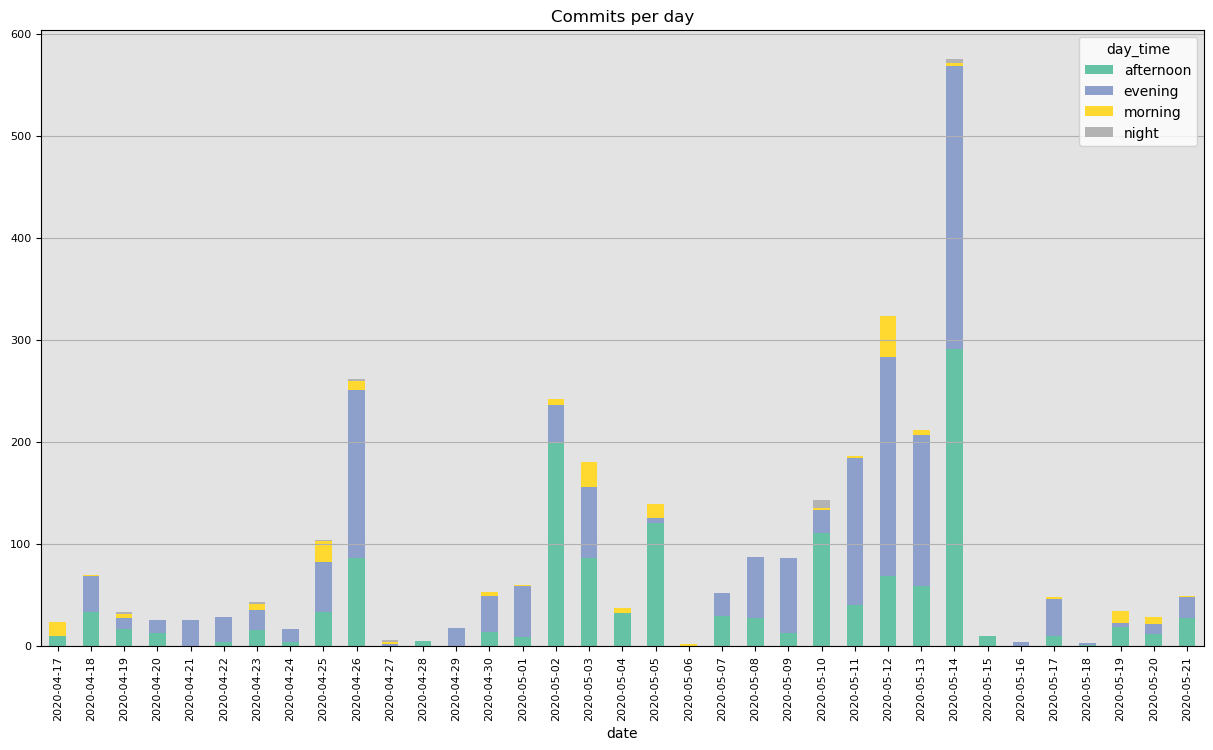

In [118]:
ax = commits.plot(kind='bar', stacked=True, figsize=(15,8), fontsize=8, colormap='Set2', legend=True)
ax.set_title('Commits per day')
ax.set_xlabel('date')
ax.tick_params(axis='x', rotation=90)
ax.grid(axis='y')
ax.set_facecolor('#E3E3E3')

## When do our users usually commit the labs: in the night, morning, afternoon, or evening?, the answer is the two most common periods.

In [119]:
df['day_time'].value_counts()

day_time
evening      1611
afternoon    1391
morning       184
night          21
Name: count, dtype: int64

Answer: evening, afternoon.

## Which day has: the most number of commits and at the same time, the number of commits in the evening is higher than in the afternoon?

In [120]:
commits[commits['evening'] > commits['afternoon']].sum(axis=1).idxmax()

datetime.date(2020, 5, 12)

Answer: 2020-5-12

In [121]:
conn.close()